# Next Period Prediction
Predice `cycle_length_days` del ciclo successivo per ogni utente usando Random Forest Regressor su feature aggregate a livello ciclo.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('menstrual_health_dataset_CLEAN.csv')
df['date'] = pd.to_datetime(df['date'])

# Aggrego a livello (user_id, cycle_index): un ciclo = una riga
cycle_df = df.groupby(['user_id', 'cycle_index']).agg(
    age=('age', 'first'),
    contraceptive_use=('contraceptive_use', 'first'),
    cycle_length_days=('cycle_length_days', 'first'),
    period_duration_days=('period_duration_days', 'first'),
    avg_pain=('pain_level', 'mean'),
    avg_mood=('mood_score', 'mean'),
    avg_fatigue=('fatigue_score', 'mean'),
    avg_stress=('stress_level', 'mean'),
    avg_sleep=('sleep_hours', 'mean'),
    avg_activity=('activity_minutes', 'mean'),
    start_date=('date', 'min')
).reset_index()

cycle_df = cycle_df.sort_values(['user_id', 'cycle_index'])
cycle_df.head()

,user_id,cycle_index,age,contraceptive_use,cycle_length_days,period_duration_days,avg_pain,avg_mood,avg_fatigue,avg_stress,avg_sleep,avg_activity,start_date
0,1,1.0,21,False,28.0,4.0,1.000000,3.535714,2.178571,2.071429,7.528571,47.214286,2024-10-16
1,1,2.0,21,False,27.0,6.0,2.407407,3.222222,3.703704,2.185185,7.133333,38.925926,2024-11-13
2,1,3.0,21,False,28.0,6.0,1.464286,3.642857,2.464286,2.107143,7.782143,46.250000,2024-12-10
3,1,4.0,21,False,39.0,7.0,2.000000,3.230769,3.794872,2.897436,6.253846,30.384615,2025-01-07
4,1,5.0,21,False,35.0,4.0,1.400000,3.542857,2.657143,2.228571,7.668571,47.971429,2025-02-15


## Feature engineering
Per ogni ciclo uso lo storico dei cicli precedenti dello stesso utente (lag, medie mobili) come predittori del **prossimo** `cycle_length_days`.

In [3]:
def build_features(g):
    g = g.copy()
    g['target_next_cycle_length'] = g['cycle_length_days'].shift(-1)
    g['prev_cycle_length'] = g['cycle_length_days'].shift(1)
    g['prev_period_duration'] = g['period_duration_days'].shift(1)
    g['rolling_mean_len_3'] = g['cycle_length_days'].shift(1).rolling(3, min_periods=1).mean()
    g['rolling_std_len_3'] = g['cycle_length_days'].shift(1).rolling(3, min_periods=1).std()
    g['cycle_number'] = range(1, len(g) + 1)
    return g

feat_df = pd.concat([build_features(g) for _, g in cycle_df.groupby('user_id')], ignore_index=True)
feat_df = feat_df.dropna(subset=['target_next_cycle_length', 'prev_cycle_length'])
feat_df['rolling_std_len_3'] = feat_df['rolling_std_len_3'].fillna(0)
feat_df.head()

,user_id,cycle_index,age,contraceptive_use,cycle_length_days,period_duration_days,avg_pain,avg_mood,avg_fatigue,avg_stress,avg_sleep,avg_activity,start_date,target_next_cycle_length,prev_cycle_length,prev_period_duration,rolling_mean_len_3,rolling_std_len_3,cycle_number
1,1,2.0,21,False,27.0,6.0,2.407407,3.222222,3.703704,2.185185,7.133333,38.925926,2024-11-13,28.0,28.0,4.0,28.000000,0.000000,2
2,1,3.0,21,False,28.0,6.0,1.464286,3.642857,2.464286,2.107143,7.782143,46.250000,2024-12-10,39.0,27.0,6.0,27.500000,0.707107,3
3,1,4.0,21,False,39.0,7.0,2.000000,3.230769,3.794872,2.897436,6.253846,30.384615,2025-01-07,35.0,28.0,6.0,27.666667,0.577350,4
4,1,5.0,21,False,35.0,4.0,1.400000,3.542857,2.657143,2.228571,7.668571,47.971429,2025-02-15,27.0,39.0,7.0,31.333333,6.658328,5
7,2,8.0,26,False,29.0,4.0,1.000000,3.689655,2.344828,1.862069,7.789655,47.275862,2023-02-25,27.0,30.0,5.0,30.000000,0.000000,2


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

features = ['age', 'contraceptive_use', 'prev_cycle_length', 'prev_period_duration',
            'rolling_mean_len_3', 'rolling_std_len_3', 'cycle_number',
            'avg_pain', 'avg_mood', 'avg_fatigue', 'avg_stress', 'avg_sleep', 'avg_activity']

feat_df['contraceptive_use'] = feat_df['contraceptive_use'].astype(int)

X = feat_df[features]
y = feat_df['target_next_cycle_length']

# Split per utente (evito leakage temporale: ultimo ciclo di ogni utente in test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print('MAE:', mean_absolute_error(y_test, pred))
print('R2:', r2_score(y_test, pred))

MAE: 3.0911257907905596
R2: -0.22085706157170404


## Feature importance

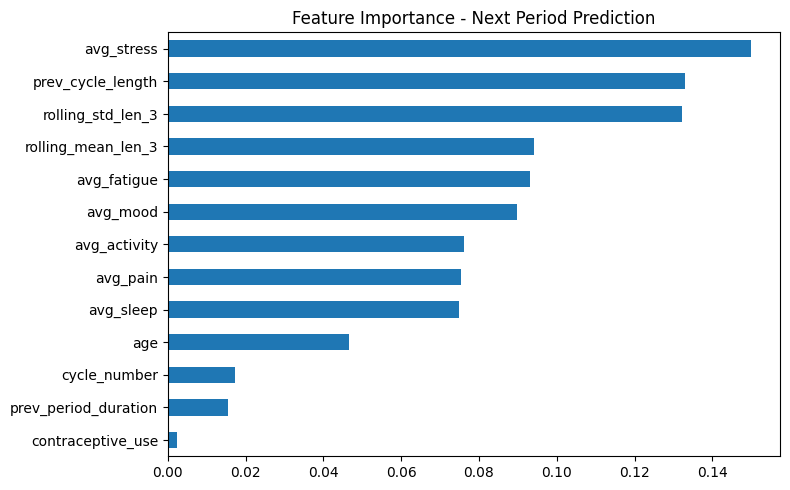

In [5]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', figsize=(8,5))
plt.title('Feature Importance - Next Period Prediction')
plt.tight_layout()
plt.show()

## Predizione per un utente specifico (esempio pratico)
Usa l'ultimo ciclo registrato per predire la durata del prossimo.

In [16]:
def predict_next_cycle(user_id):
    user_hist = feat_df[feat_df['user_id'] == user_id]
    if user_hist.empty:
        last = cycle_df[cycle_df['user_id'] == user_id].sort_values('cycle_index')
        return f"Utente {user_id}: storico insufficiente per predizione (cold start)."
    row = user_hist.iloc[[-1]][features]
    pred_len = model.predict(row)[0]
    return f"Utente {user_id}: prossimo ciclo stimato in {pred_len:.1f} giorni."



for i in range(1,51):
    print(predict_next_cycle(i))

Utente 1: prossimo ciclo stimato in 27.1 giorni.
Utente 2: prossimo ciclo stimato in 28.0 giorni.
Utente 3: prossimo ciclo stimato in 27.7 giorni.
Utente 4: prossimo ciclo stimato in 29.2 giorni.
Utente 5: prossimo ciclo stimato in 27.8 giorni.
Utente 6: prossimo ciclo stimato in 28.0 giorni.
Utente 7: prossimo ciclo stimato in 28.4 giorni.
Utente 8: prossimo ciclo stimato in 28.0 giorni.
Utente 9: prossimo ciclo stimato in 28.1 giorni.
Utente 10: prossimo ciclo stimato in 27.7 giorni.
Utente 11: prossimo ciclo stimato in 27.8 giorni.
Utente 12: prossimo ciclo stimato in 27.8 giorni.
Utente 13: prossimo ciclo stimato in 27.9 giorni.
Utente 14: prossimo ciclo stimato in 28.1 giorni.
Utente 15: prossimo ciclo stimato in 27.6 giorni.
Utente 16: prossimo ciclo stimato in 27.8 giorni.
Utente 17: prossimo ciclo stimato in 27.7 giorni.
Utente 18: prossimo ciclo stimato in 27.9 giorni.
Utente 19: prossimo ciclo stimato in 28.1 giorni.
Utente 20: prossimo ciclo stimato in 31.1 giorni.
Utente 21